##  BÀI TẬP 2.2
#### **Họ và tên:** Nguyễn Quang Linh  
#### **MSSV:** 038205003016

## Import lib and load dataset 
### 1. Nạp dự liệu iris vào bộ nhớ và hiển thị thông tin về số thuộc tính (dimensionality), số objects (size).

In [25]:
import pandas as pd 
from sklearn.datasets import load_iris 

iris = load_iris()
X = iris.data
Y = iris.target 

# 1. Nạp dự liệu iris vào bộ nhớ và hiển thị thông tin về số thuộc tính (dimensionality), số objects (size).
n_samples, n_features = X.shape
print(f"Number of features:{n_features}")
print(f"Number off samples:{n_samples}")


Number of features:4
Number off samples:150


### 2. Đặt nhãn (label) cho dữ liệu đã nạp và hiển thị số lớp (classes)

In [26]:
print(f"Set labels for target variable {iris.target_names}")
print(f"Number of classes: {len(iris.target_names)}")

Set labels for target variable ['setosa' 'versicolor' 'virginica']
Number of classes: 3


### 3. Tách dữ liệu thành hai phần: training data(70%) và test data (30%)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
  x,y, test_size = 0.3, random_state = 42
)
print(f"Size of training set: {X_train.shape[0]} samples")
print(f"Size of training set: {X_test.shape[0]} samples")

Size of training set: 105 samples
Size of training set: 45 samples


### 4. Chuẩn hóa dữ liệu với StandardScaler

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### 5. Tạo và huấn luyện mô hình với training data

In [29]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(criterion='gini',random_state=42)
clf.fit(X_train,Y_train)

print(f"Done successfully training the model.")

Done successfully training the model.


### 6. Đánh giá mô hình (Evaluation)  confusion matrix, accuracy, f-score

Accuracy: 1.00
F1-score: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Heatmap visualization of the confusion matrix


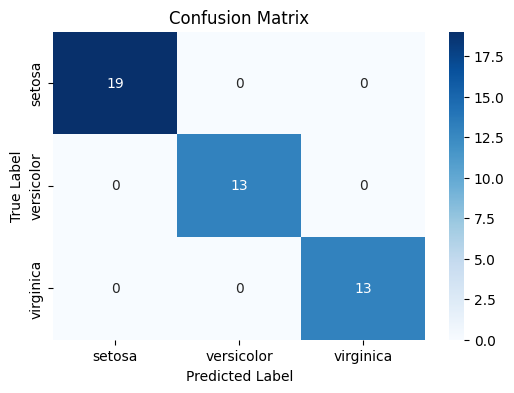

In [40]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

Y_predict = clf.predict(X_test)

accuracy = accuracy_score(Y_test, Y_predict)
print(f"Accuracy: {accuracy:.2f}")
f1 = f1_score(Y_test, Y_predict, average='macro')
print(f"F1-score: {f1:.2f}")
cm = confusion_matrix(Y_test, Y_predict)
print(f"Confusion Matrix:\n{cm}")

print(f"Heatmap visualization of the confusion matrix")
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### 7. Trực quan hóa cây quyết định

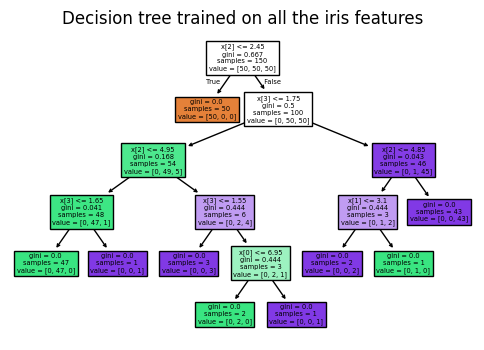

In [42]:
from sklearn.tree import plot_tree
plt.figure(figsize=(6,4))
clf = DecisionTreeClassifier().fit(iris.data, iris.target)
plot_tree(clf, filled=True)
plt.title("Decision tree trained on all the iris features")
plt.show()
